# Fraud Detection Model

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib

df = pd.read_csv("Fraud detection .csv")

In [15]:
# Remove rows with missing target values
df = df.dropna(subset=["Class"])

# Create features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train,y_train)

pred = model.predict(X_test)

# Print the classification report
print(classification_report(y_test,pred))

# Print the confusion matrix
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8315
         1.0       0.94      0.73      0.82        22

    accuracy                           1.00      8337
   macro avg       0.97      0.86      0.91      8337
weighted avg       1.00      1.00      1.00      8337

[[8314    1]
 [   6   16]]


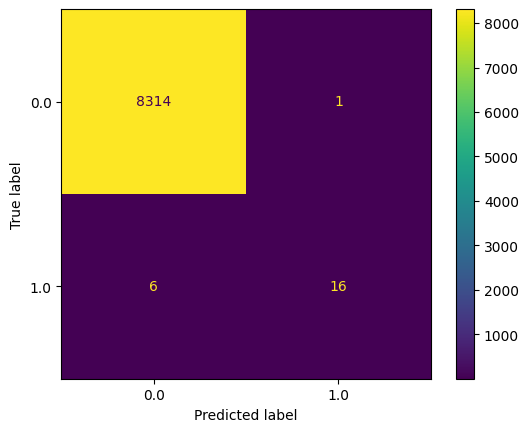

In [17]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

In [20]:
joblib.dump(model,"fraud_model.pkl")
print("Saved fraud_model.pkl")

Saved fraud_model.pkl


# Overspending Prediction Model

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import joblib

df = pd.read_csv("Overspending prediction .csv")

In [31]:
budget_col="budget_goal"
expense_col="monthly_expense_total"

df["Overspending"]=(df[expense_col]>df[budget_col]).astype(int)

X=df.drop(columns=["Overspending"])
y=df["Overspending"]

# save the column names
feature_names=X.columns

# Remove non-numeric columns or encode them as needed
X=pd.get_dummies(X,drop_first=True)

imp=SimpleImputer(strategy="median")
X=imp.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


In [32]:
model=RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

pred=model.predict(X_test)
print(classification_report(y_test,pred))



              precision    recall  f1-score   support

           0       0.98      0.93      0.95       245
           1       0.95      0.99      0.97       355

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



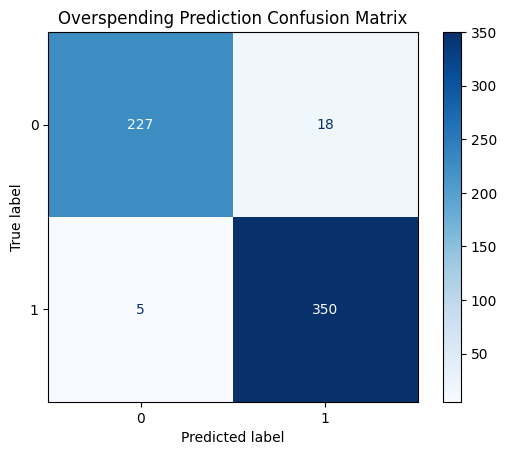

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Overspending Prediction Confusion Matrix")
plt.show()

In [36]:
joblib.dump(model,"overspending_model.pkl")
joblib.dump(imp,"overspending_imputer.pkl")
print("Saved overspending_model.pkl")

Saved overspending_model.pkl
